# Logistic Regression from Scratch

Binary classification predicting **obesity from body weight (grams)** in rats, using a logistic regression model implemented from scratch with gradient descent (NumPy only), then evaluated with scikit-learn metrics.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

## Load Dataset

In [2]:
""" 
Body weight (g) -> obese (1) / not obese (0).
overlap lowers training accuracy (the model literally cannot get those two points right), but it
makes the experiment realistic and the evaluation meaningful.
"""
X_train = np.array([
    [240],
    [250],
    [260],
    [270],
    [285],
    [295],
    [305],
    [335],
    [345],
    [355],
    [365],
    [375],
    [385],
    [395],
    [405],
    [415]
])

y_train = np.array([0, 0, 0, 0, 0, 0, 0,1, 1, 1, 1, 1, 1, 1, 1, 1])

print("X-> y mapping")
for x, y in zip(X_train, y_train):
  print(f"{x} -> {y}")




X_test = np.array([
    [290],
    [310],
    [320],
    [330],
    [350],
    [400]
])

y_test = np.array([0, 0, 1, 1, 1, 1])

# Standardize features using TRAIN statistics only.
# Large raw values (240-415) make the gradients explode, so the
# loss oscillates instead of converging. Scaling fixes that.
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_train = (X_train - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

X-> y mapping
[240] -> 0
[250] -> 0
[260] -> 0
[270] -> 0
[285] -> 0
[295] -> 0
[305] -> 0
[335] -> 1
[345] -> 1
[355] -> 1
[365] -> 1
[375] -> 1
[385] -> 1
[395] -> 1
[405] -> 1
[415] -> 1


In [3]:
class LogisticRegressionScratch:

    def __init__(self, learning_rate=0.001, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y, y_pred):
        return -np.mean(
            y * np.log(y_pred + 1e-15) +
            (1 - y) * np.log(1 - y_pred + 1e-15)
        )

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):

            z = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(z)

            loss = self.compute_loss(y, y_pred)

            self.loss_history.append(loss)

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            if epoch % 100 == 0:
                print(f"Epoch {epoch}: Loss = {loss:.4f}")

    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)

    def predict(self, X):
        probs = self.predict_proba(X)
        return (probs >= 0.5).astype(int)


model =  LogisticRegressionScratch(learning_rate = 0.01, epochs = 3000)      
model.fit(X_train, y_train)

Epoch 0: Loss = 0.6931
Epoch 100: Loss = 0.5316
Epoch 200: Loss = 0.4306
Epoch 300: Loss = 0.3638
Epoch 400: Loss = 0.3170
Epoch 500: Loss = 0.2825
Epoch 600: Loss = 0.2560
Epoch 700: Loss = 0.2351
Epoch 800: Loss = 0.2181
Epoch 900: Loss = 0.2039
Epoch 1000: Loss = 0.1919
Epoch 1100: Loss = 0.1817
Epoch 1200: Loss = 0.1728
Epoch 1300: Loss = 0.1649
Epoch 1400: Loss = 0.1580
Epoch 1500: Loss = 0.1517
Epoch 1600: Loss = 0.1461
Epoch 1700: Loss = 0.1411
Epoch 1800: Loss = 0.1364
Epoch 1900: Loss = 0.1322
Epoch 2000: Loss = 0.1283
Epoch 2100: Loss = 0.1247
Epoch 2200: Loss = 0.1213
Epoch 2300: Loss = 0.1182
Epoch 2400: Loss = 0.1153
Epoch 2500: Loss = 0.1126
Epoch 2600: Loss = 0.1100
Epoch 2700: Loss = 0.1076
Epoch 2800: Loss = 0.1053
Epoch 2900: Loss = 0.1032


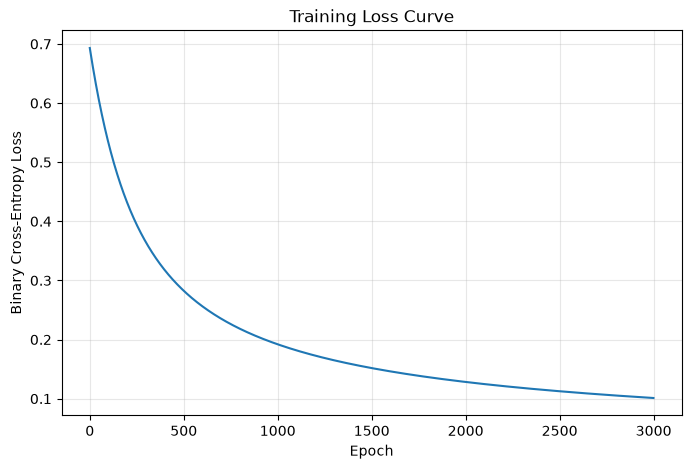

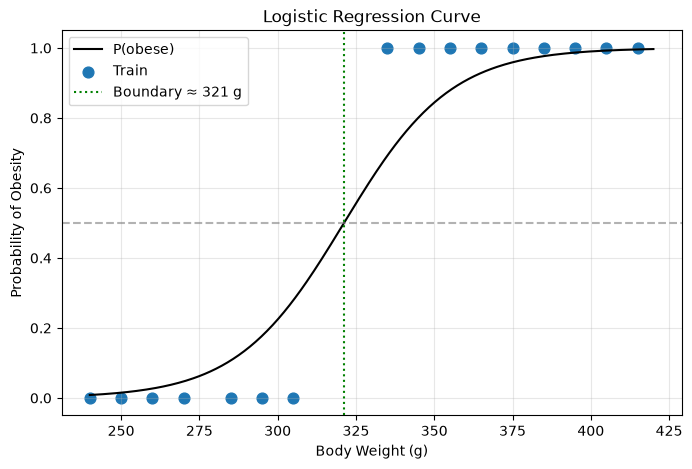

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(model.loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.show()


# Logistic Regression Curve: P(obese) vs body weight.
# Smooth grid of weights (in original grams), standardized the same way as training.
grid = np.linspace(240, 420, 300).reshape(-1, 1)
grid_scaled = (grid - X_mean) / X_std
grid_probs = model.predict_proba(grid_scaled)

# Recover original gram values of the train points (they were standardized).
X_train_orig = X_train * X_std + X_mean

plt.figure(figsize=(8, 5))
plt.plot(grid, grid_probs, color="black", label="P(obese)")
plt.scatter(X_train_orig, y_train, color="tab:blue", s=60, label="Train")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.6)

# Decision boundary: weight where P(obese) = 0.5
boundary = X_mean[0] - (model.bias / model.weights[0]) * X_std[0]
plt.axvline(boundary, color="green", linestyle=":", label=f"Boundary ≈ {boundary:.0f} g")

plt.title("Logistic Regression Curve")
plt.xlabel("Body Weight (g)")
plt.ylabel("Probability of Obesity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Predict on a New Rat

Any new input must go through the **same preprocessing as training**: standardize
with the train statistics (`X_mean`, `X_std`) and pass a 2D array of shape `(n, 1)`.
Feeding raw grams (e.g. `model.predict(100)`) gives a meaningless result because the
model learned weights on the standardized scale.

In [18]:
# Predict on brand-new rats.
# Standardize with the SAME train statistics, shaped (n, 1).
new_weights = np.array([[100], [300], [380]])   # grams
new_scaled = (new_weights - X_mean) / X_std

preds = model.predict(new_scaled)
probs = model.predict_proba(new_scaled)

for grams, p, prob in zip(new_weights.ravel(), preds, probs):
    label = "obese" if p == 1 else "not obese"
    print(f"{grams:>4} g -> {label:>9}  (P(obese) = {prob:.3f})")

 100 g -> not obese  (P(obese) = 0.000)
 300 g -> not obese  (P(obese) = 0.224)
 380 g ->     obese  (P(obese) = 0.969)


## Evaluation Metrics

In [12]:
print("Test rat")
test_rat = model.predict(100)
print(test_rat)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1 Score   : {f1:.4f}")
print(f"ROC AUC    : {roc_auc_score(y_test, y_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Test rat
[1]
Accuracy   : 0.8333
Precision  : 1.0000
Recall     : 0.7500
F1 Score   : 0.8571
ROC AUC    : 1.0000

Confusion Matrix:
[[2 0]
 [1 3]]
